# 18 · What fine-tuning does to the ranking (588689)

Head-FT (N=300, mean of five seeds) and No-FT rank the same 49,685 held-out compounds (396 active). This notebook looks at the **molecules whose position changes**: with a top-1% cut (497 compounds), which actives does fine-tuning promote into the top and which does it lose, which false positives does it remove and which new ones does it create. Each group is drawn, with the rank under No-FT then under head-FT, and its properties are compared.

In [1]:

import json, numpy as np, pandas as pd, matplotlib as mpl, matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display
from scipy import stats
from rdkit import Chem, RDLogger
from rdkit.Chem import Draw, Descriptors, Crippen, rdMolDescriptors
RDLogger.DisableLog("rdApp.*")
BLK="#000000"; GRN="#1baf7a"; CL="#d62728"; CO="#2a78d6"; NEU="#666666"; ORG="#e08a1e"
mpl.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","savefig.facecolor":"white",
  "text.color":BLK,"axes.labelcolor":BLK,"axes.titlecolor":BLK,"xtick.color":BLK,"ytick.color":BLK,
  "axes.edgecolor":BLK,"font.size":10,"font.weight":"normal","axes.titleweight":"normal","axes.labelweight":"normal",
  "axes.grid":True,"grid.color":"#e6e6e6","axes.axisbelow":True,"axes.spines.top":False,"axes.spines.right":False})
ROOT=Path("/global/scratch/users/sergiomar10/boltzaff"); T="588689"; A=ROOT/"results/analysis"/T/"cliffs"
S=pd.read_csv(A/"scores_seeds_eval.csv").set_index("id"); SEEDS=[f"ft_p{s}" for s in range(5)]
S["ft"]=S[SEEDS].mean(axis=1)
raw=pd.read_csv(ROOT/f"data/mf-pcba_test/{T}.csv"); raw["id"]=f"{T}_"+raw.CID.astype(str); S["smiles"]=raw.set_index("id")["neut-smiles"].reindex(S.index).values
N=len(S); K=int(round(0.01*N)); y=S.label.values
S["rank_noft"]=S.noft_p.rank(ascending=False,method="first").astype(int); S["rank_ft"]=S.ft.rank(ascending=False,method="first").astype(int)
S["in_noft"]=S.rank_noft<=K; S["in_ft"]=S.rank_ft<=K
pairs=pd.read_csv(A/"pairs.csv"); SIB=set(pairs[pairs.kind=="cliff"].id_b)          # inactive near-identical partners of held-out actives
S["sibling"]=S.index.isin(SIB)
G={"promoted actives":(S.label==1)&S.in_ft&~S.in_noft,"lost actives":(S.label==1)&S.in_noft&~S.in_ft,
   "kept actives":(S.label==1)&S.in_ft&S.in_noft,
   "demoted false positives":(S.label==0)&S.in_noft&~S.in_ft,"new false positives":(S.label==0)&S.in_ft&~S.in_noft,"kept false positives":(S.label==0)&S.in_ft&S.in_noft}
print(f"held-out eval set: {N:,} compounds, {int(y.sum())} active; top 1% = {K} compounds")
print({k:int(v.sum()) for k,v in G.items()})
def draw(df,n,title,by,asc):
    d=df.sort_values(by,ascending=asc).head(n); mols=[Chem.MolFromSmiles(s) for s in d.smiles]
    leg=[f"{i.split('_')[-1]}  rank {int(r.rank_noft):,} -> {int(r.rank_ft):,}" for i,r in d.iterrows()]
    ok=[i for i,m in enumerate(mols) if m is not None]
    print(title); display(Draw.MolsToGridImage([mols[i] for i in ok],molsPerRow=4,subImgSize=(300,230),legends=[leg[i] for i in ok],returnPNG=False))


held-out eval set: 49,685 compounds, 396 active; top 1% = 497 compounds
{'promoted actives': 76, 'lost actives': 18, 'kept actives': 49, 'demoted false positives': 334, 'new false positives': 276, 'kept false positives': 96}


## 1. Every compound, before and after
Rank under No-FT against rank under head-FT (1 = best, log scales). The dashed lines mark the top 1%. Actives are drawn on top: points above the diagonal moved up under fine-tuning.

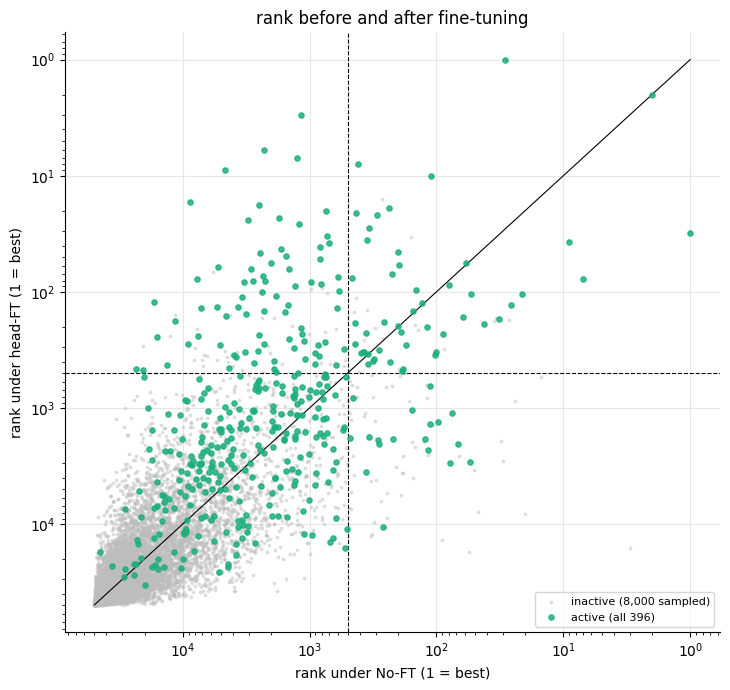

In [2]:
fig,ax=plt.subplots(figsize=(7.4,7))
ina=S[S.label==0].sample(n=8000,random_state=0)
ax.scatter(ina.rank_noft,ina.rank_ft,s=3,color="#bdbdbd",alpha=0.4,label="inactive (8,000 sampled)",rasterized=True)
a=S[S.label==1]; ax.scatter(a.rank_noft,a.rank_ft,s=14,color=GRN,alpha=0.85,label=f"active (all {len(a)})",zorder=3)
ax.plot([1,N],[1,N],color=BLK,lw=0.8); ax.axvline(K,ls="--",color=BLK,lw=0.8); ax.axhline(K,ls="--",color=BLK,lw=0.8)
ax.set_xscale("log"); ax.set_yscale("log"); ax.invert_xaxis(); ax.invert_yaxis(); ax.set_xlabel("rank under No-FT (1 = best)"); ax.set_ylabel("rank under head-FT (1 = best)"); ax.legend(fontsize=8,loc="lower right")
ax.set_title("rank before and after fine-tuning"); plt.tight_layout(); plt.show()

## 2. Who enters and leaves the top 1%
Counts of actives and inactives by whether they are in the top 1% under each model.

,both,only_NoFT,only_headFT,neither
label,,,,
active,49,18,76,253
inactive,96,334,276,48583


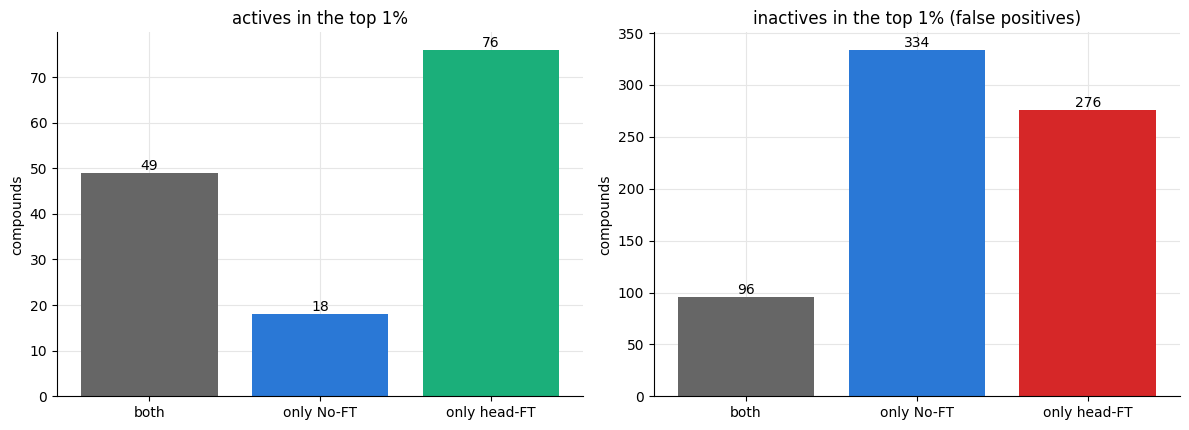

actives in the top 1%: No-FT 67, head-FT 125; false positives: No-FT 430, head-FT 372


In [3]:
rows=[]
for lab in (1,0):
    d=S[S.label==lab]
    rows.append(dict(label="active" if lab else "inactive",both=int((d.in_noft&d.in_ft).sum()),only_NoFT=int((d.in_noft&~d.in_ft).sum()),only_headFT=int((~d.in_noft&d.in_ft).sum()),neither=int((~d.in_noft&~d.in_ft).sum())))
T2=pd.DataFrame(rows).set_index("label"); display(T2)
fig,axes=plt.subplots(1,2,figsize=(12,4.4))
for ax,lab,ttl in [(axes[0],"active","actives in the top 1%"),(axes[1],"inactive","inactives in the top 1% (false positives)")]:
    r=T2.loc[lab]; ax.bar(["both","only No-FT","only head-FT"],[r.both,r.only_NoFT,r.only_headFT],color=[NEU,CO,CL if lab=="inactive" else GRN])
    for i,v in enumerate([r.both,r.only_NoFT,r.only_headFT]): ax.text(i,v,int(v),ha="center",va="bottom")
    ax.set_ylabel("compounds"); ax.set_title(ttl)
plt.tight_layout(); plt.show()
print(f"actives in the top 1%: No-FT {int(S[(S.label==1)&S.in_noft].shape[0])}, head-FT {int(S[(S.label==1)&S.in_ft].shape[0])}; false positives: No-FT {int(S[(S.label==0)&S.in_noft].shape[0])}, head-FT {int(S[(S.label==0)&S.in_ft].shape[0])}")

## 3. How far do compounds move?
log2 of (No-FT rank divided by head-FT rank): positive means fine-tuning moved the compound up. Actives are moved up much more than inactives on average, but some actives move down.

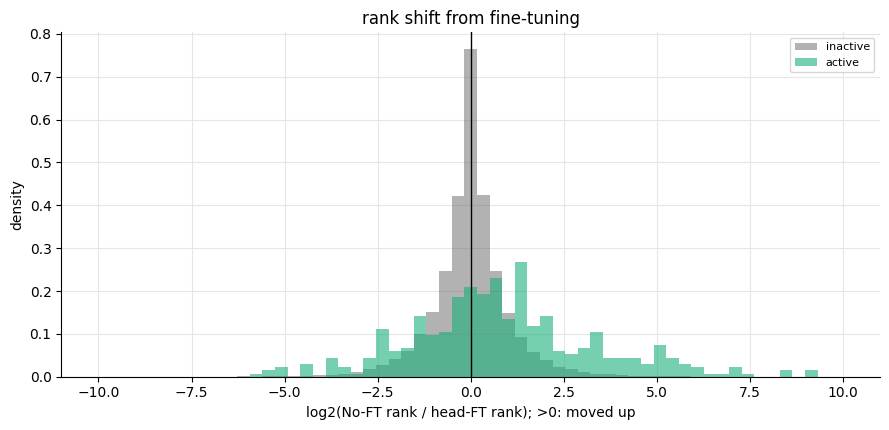

actives: median shift +0.67 (x1.59 in rank), moved up 64%, moved up by >4x 27%, moved down by >4x 11%
inactives: median shift -0.00 (x1.00 in rank), moved up 50%, moved up by >4x 3%, moved down by >4x 3%


In [4]:
S["rank_shift"]=np.log2(S.rank_noft/S.rank_ft)
fig,ax=plt.subplots(figsize=(9,4.4)); b=np.linspace(-10,10,60)
ax.hist(S[S.label==0]["rank_shift"].clip(-10,10),bins=b,density=True,alpha=0.5,color=NEU,label="inactive"); ax.hist(S[S.label==1]["rank_shift"].clip(-10,10),bins=b,density=True,alpha=0.6,color=GRN,label="active")
ax.axvline(0,color=BLK,lw=1); ax.set_xlabel("log2(No-FT rank / head-FT rank); >0: moved up"); ax.set_ylabel("density"); ax.legend(fontsize=8); ax.set_title("rank shift from fine-tuning")
plt.tight_layout(); plt.show()
for lab,nm in [(1,"actives"),(0,"inactives")]:
    d=S[S.label==lab]["rank_shift"]; print(f"{nm}: median shift {d.median():+.2f} (x{2**d.median():.2f} in rank), moved up {100*(d>0).mean():.0f}%, moved up by >4x {100*(d>2).mean():.0f}%, moved down by >4x {100*(d<-2).mean():.0f}%")

## 4. The actives fine-tuning promotes
Actives that head-FT puts in the top 1% and No-FT does not, ordered by how far they rise (rank under No-FT, then under head-FT).

76 promoted actives
Promoted actives (largest rise first)


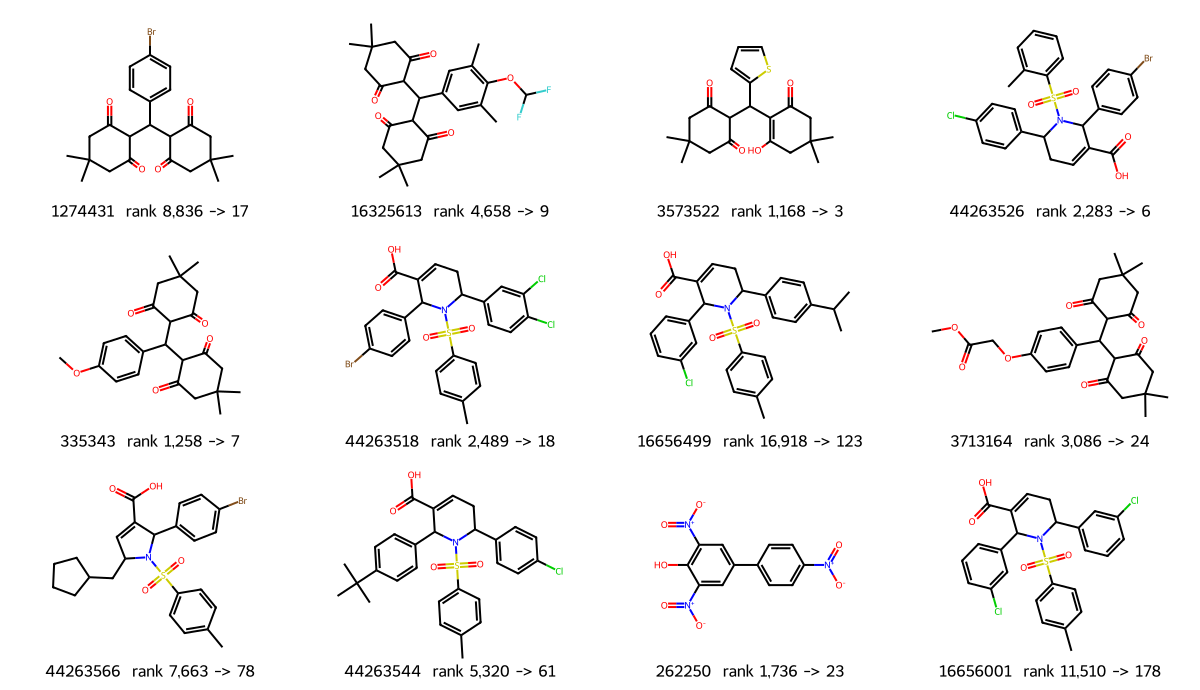

In [5]:
d=S[G["promoted actives"]]; print(f"{len(d)} promoted actives")
draw(d,12,"Promoted actives (largest rise first)","rank_shift",False)

## 5. The actives fine-tuning loses
Actives that No-FT has in the top 1% and head-FT pushes out, ordered by how far they fall.

18 lost actives
Lost actives (largest fall first)


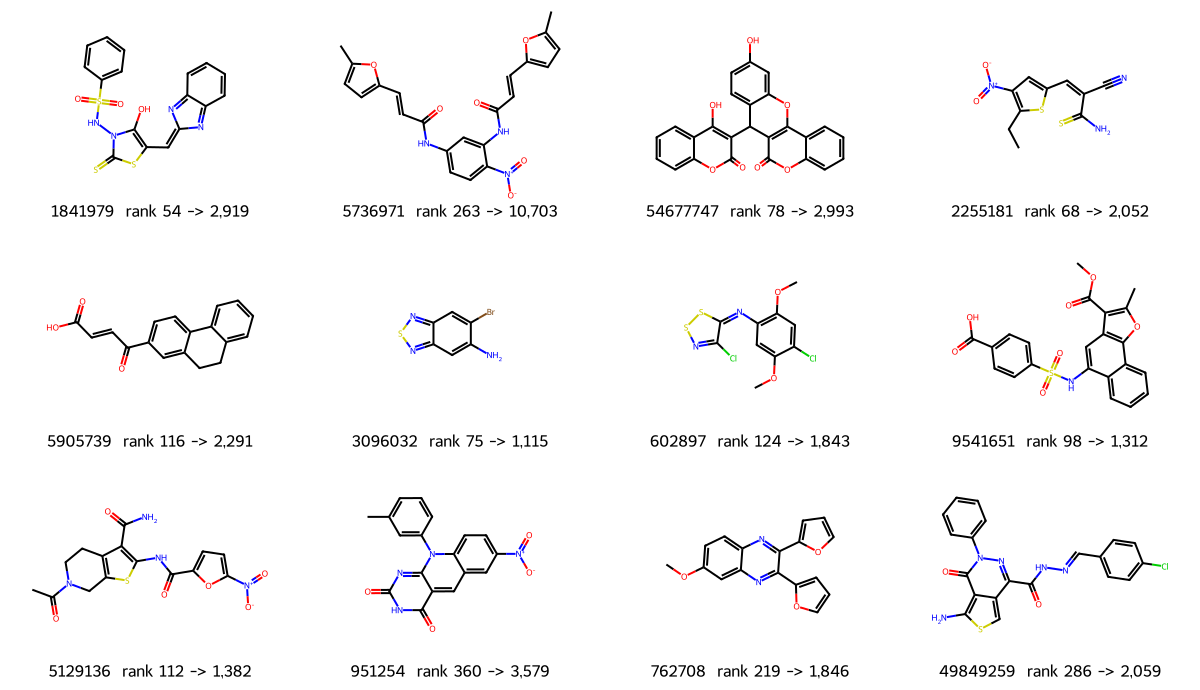

In [6]:
d=S[G["lost actives"]]; print(f"{len(d)} lost actives")
draw(d,12,"Lost actives (largest fall first)","rank_shift",True)

## 6. The false positives fine-tuning removes
Inactives in No-FT's top 1% that head-FT pushes out, ordered by how far they fall.

334 demoted false positives
Demoted false positives (largest fall first)


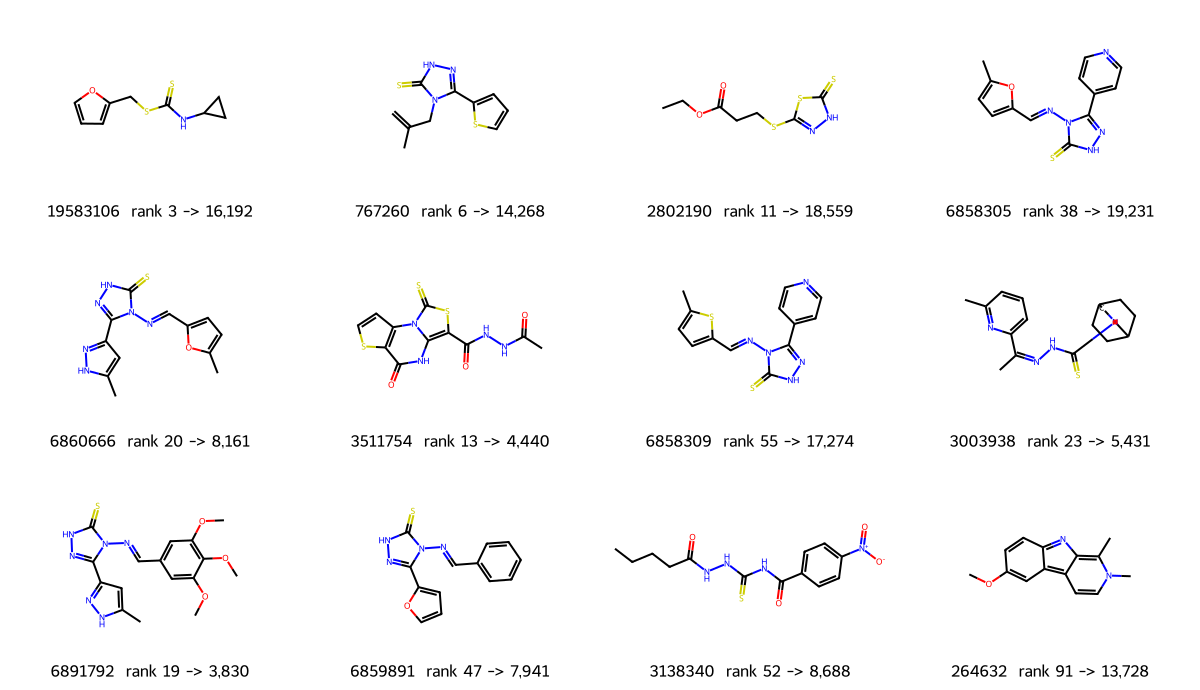

In [7]:
d=S[G["demoted false positives"]]; print(f"{len(d)} demoted false positives")
draw(d,12,"Demoted false positives (largest fall first)","rank_shift",True)

## 7. The new false positives fine-tuning creates
Inactives that head-FT puts in the top 1% and No-FT does not, ordered by how high head-FT ranks them.

276 new false positives; 23 are near-identical (Tanimoto >= 0.6) to a held-out active
New false positives (highest head-FT rank first)


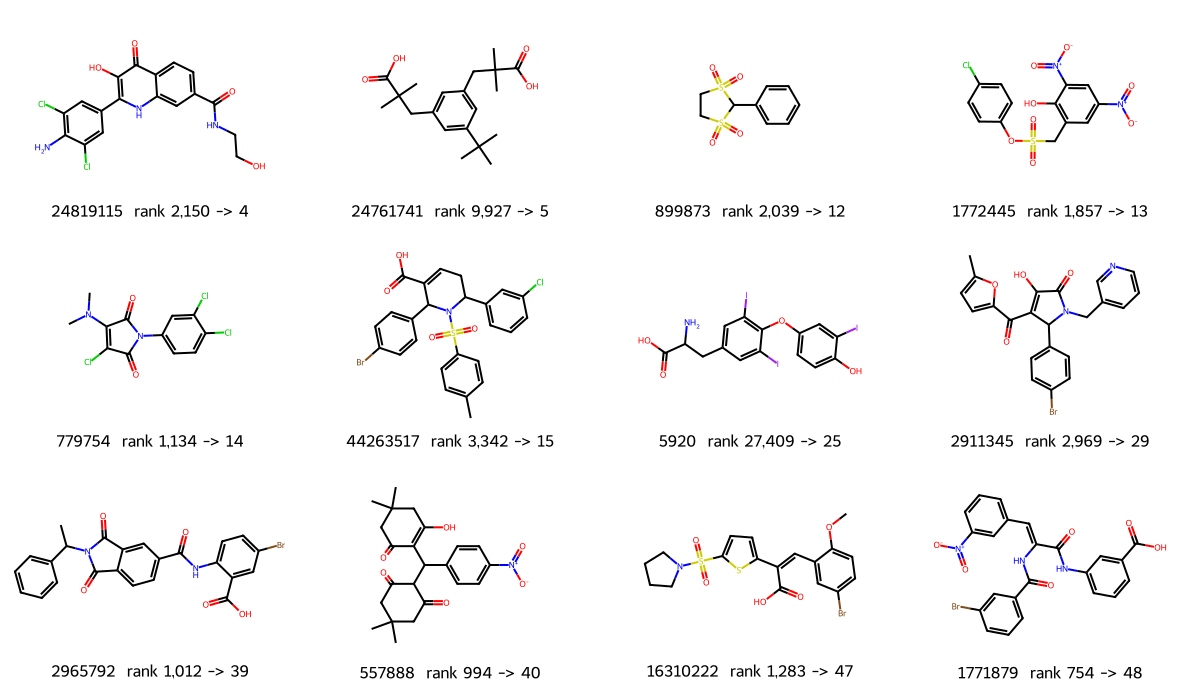

In [8]:
d=S[G["new false positives"]]; print(f"{len(d)} new false positives; {int(d.sibling.sum())} are near-identical (Tanimoto >= 0.6) to a held-out active")
draw(d,12,"New false positives (highest head-FT rank first)","rank_ft",True)

## 8. What the groups have in common
RDKit properties of each group. If fine-tuning were mostly learning 'bigger and greasier', the promoted compounds would be larger and more lipophilic than the ones it removes.

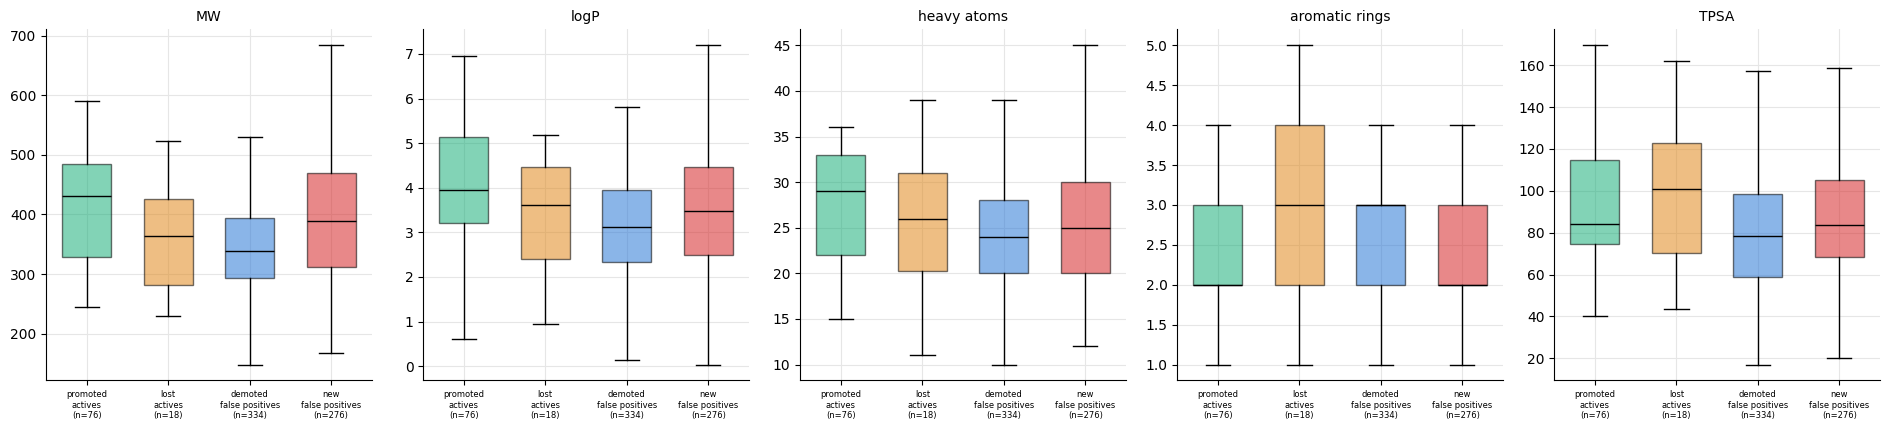

,MW,logP,heavy atoms,aromatic rings,TPSA
promoted actives,430.15,3.96,29.0,2.0,84.29
lost actives,363.34,3.60,26.0,3.0,100.77
demoted false positives,339.30,3.12,24.0,3.0,78.56
new false positives,388.74,3.48,25.0,2.0,83.47


MW: promoted actives median 430.15 vs demoted false positives 339.30 (Mann-Whitney p=4.9e-09)
logP: promoted actives median 3.96 vs demoted false positives 3.12 (Mann-Whitney p=1.5e-06)
MW: new false positives median 388.74 vs demoted false positives 339.30 (Mann-Whitney p=2.3e-08)
logP: new false positives median 3.48 vs demoted false positives 3.12 (Mann-Whitney p=0.0021)


In [9]:
def props(smi):
    m=Chem.MolFromSmiles(smi); return (Descriptors.MolWt(m),Crippen.MolLogP(m),m.GetNumHeavyAtoms(),rdMolDescriptors.CalcNumAromaticRings(m),rdMolDescriptors.CalcTPSA(m)) if m else (np.nan,)*5
order=["promoted actives","lost actives","demoted false positives","new false positives"]; PR={}
for g in order:
    d=S[G[g]]; PR[g]=pd.DataFrame([props(s) for s in d.smiles],columns=["MW","logP","heavy atoms","aromatic rings","TPSA"],index=d.index)
fig,axes=plt.subplots(1,5,figsize=(19,4.4)); cols=[GRN,ORG,CO,CL]
for ax,c in zip(axes,["MW","logP","heavy atoms","aromatic rings","TPSA"]):
    labs=[g.replace(" ","\n",1)+"\n(n="+str(len(PR[g]))+")" for g in order]
    bp=ax.boxplot([PR[g][c].dropna() for g in order],tick_labels=labs,showfliers=False,patch_artist=True,widths=0.6,medianprops=dict(color=BLK))
    for p,col in zip(bp["boxes"],cols): p.set_facecolor(col); p.set_alpha(0.55)
    ax.set_title(c,fontsize=10); ax.tick_params(axis="x",labelsize=6)
plt.tight_layout(); plt.show()
display(pd.DataFrame({g:PR[g].median() for g in order}).T.round(2))
for a_,b_ in [("promoted actives","demoted false positives"),("new false positives","demoted false positives")]:
    for c in ["MW","logP"]:
        x,z=PR[a_][c].dropna(),PR[b_][c].dropna(); print(f"{c}: {a_} median {x.median():.2f} vs {b_} {z.median():.2f} (Mann-Whitney p={stats.mannwhitneyu(x,z).pvalue:.2g})")

## 9. Is the shift explained by size or lipophilicity across the whole library?
Correlation of each compound's rank shift with its molecular weight and logP, over a random 10,000 compounds plus all actives.

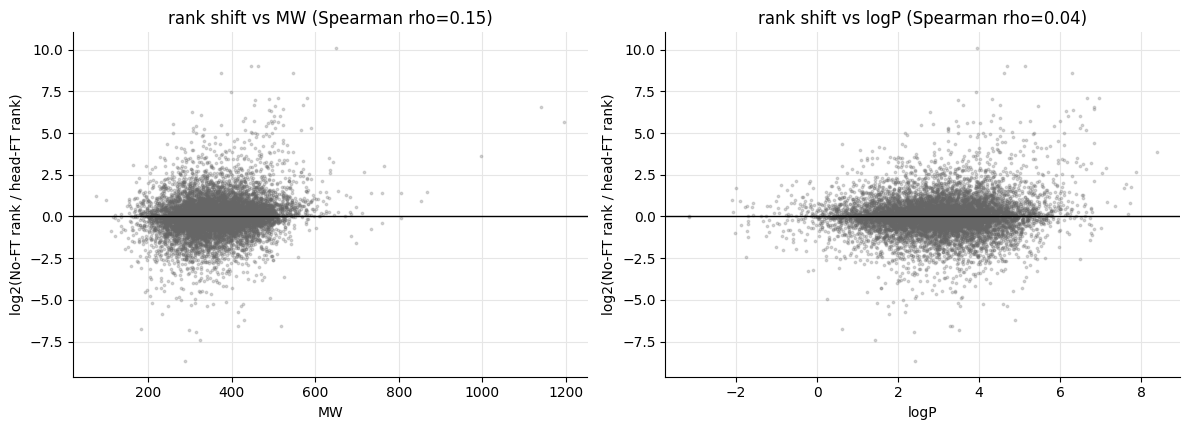

In [10]:
samp=pd.concat([S.sample(n=10000,random_state=0),S[S.label==1]]).drop_duplicates(); pp=pd.DataFrame([props(s) for s in samp.smiles],columns=["MW","logP","heavy","arom","TPSA"],index=samp.index)
fig,axes=plt.subplots(1,2,figsize=(12,4.4))
for ax,c in zip(axes,["MW","logP"]):
    ax.scatter(pp[c],samp["rank_shift"],s=3,alpha=0.25,color=NEU,rasterized=True); ax.axhline(0,color=BLK,lw=1); r,p=stats.spearmanr(pp[c],samp["rank_shift"],nan_policy="omit")
    ax.set_xlabel(c); ax.set_ylabel("log2(No-FT rank / head-FT rank)"); ax.set_title(f"rank shift vs {c} (Spearman rho={r:.2f})")
plt.tight_layout(); plt.show()

## 10. Are the promoted compounds analogs of what the model was trained on?
Fine-tuning used 300 training compounds, 90 of them active, none of which are in the evaluation set. But the evaluation set can still contain close analogs of those 90 actives. For each compound, its highest ECFP4 Tanimoto to any of the 90 training actives. If the promoted actives (and the new false positives) sit much closer to the training actives than the lost actives and the demoted false positives do, then much of the gain, and much of the cost, is fine-tuning recognising chemical families it was shown.

300 training compounds, 90 active


,n,median max-Tanimoto to a training active,% >= 0.5,% >= 0.6
group,,,,
promoted actives,76,0.47,42.11,27.63
lost actives,18,0.31,11.11,5.56
kept actives,49,0.41,38.78,32.65
new false positives,276,0.26,6.16,1.81
demoted false positives,334,0.23,1.80,0.90
kept false positives,96,0.26,9.38,5.21
all held-out actives,396,0.28,17.93,11.36
random inactives (500),500,0.22,0.60,0.40


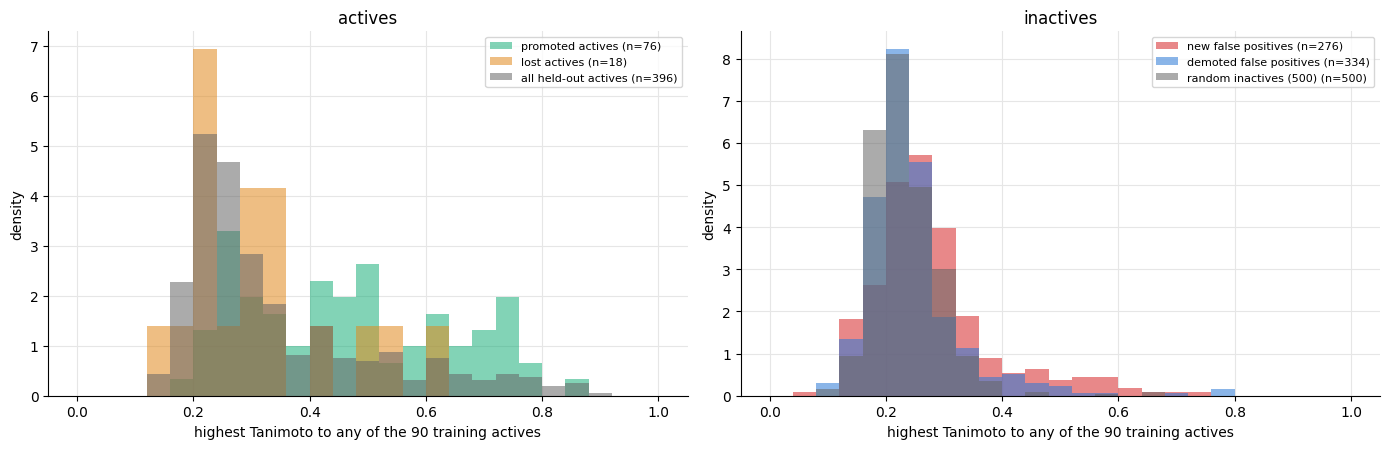

promoted actives vs lost actives: median 0.47 vs 0.31, Mann-Whitney p=0.001
promoted actives vs all held-out actives: median 0.47 vs 0.28, Mann-Whitney p=4.1e-09
new false positives vs demoted false positives: median 0.26 vs 0.23, Mann-Whitney p=7.5e-07
new false positives vs random inactives (500): median 0.26 vs 0.22, Mann-Whitney p=3.7e-12


In [11]:
from rdkit import DataStructs
from rdkit.Chem import rdFingerprintGenerator
gen=rdFingerprintGenerator.GetMorganGenerator(radius=2,fpSize=2048)
tr=[l.strip() for l in open(ROOT/f"results/runs/{T}/ft_inputs_full/train_ids_top300.txt") if l.strip()]
lab_all=raw.set_index("id").target_active_v2; tr_act=[t for t in tr if lab_all.get(t,False)]
trfp=[gen.GetFingerprint(Chem.MolFromSmiles(raw.set_index("id")["neut-smiles"][t])) for t in tr_act]
def nn_sim(smis):
    out=[]
    for s in smis:
        m=Chem.MolFromSmiles(s); out.append(max(DataStructs.BulkTanimotoSimilarity(gen.GetFingerprint(m),trfp)) if m else np.nan)
    return np.array(out)
print(f"{len(tr)} training compounds, {len(tr_act)} active")
grp=["promoted actives","lost actives","kept actives","new false positives","demoted false positives","kept false positives"]; NN={}
for g in grp: NN[g]=nn_sim(S[G[g]].smiles)
NN["all held-out actives"]=nn_sim(S[S.label==1].smiles); NN["random inactives (500)"]=nn_sim(S[S.label==0].sample(n=500,random_state=0).smiles)
rows=[(g,len(v),np.nanmedian(v),100*np.nanmean(v>=0.5),100*np.nanmean(v>=0.6)) for g,v in NN.items()]
T10=pd.DataFrame(rows,columns=["group","n","median max-Tanimoto to a training active","% >= 0.5","% >= 0.6"]).set_index("group"); display(T10.round(2))
fig,axes=plt.subplots(1,2,figsize=(14,4.6)); b=np.linspace(0,1,26)
for ax,gs,cs in [(axes[0],["promoted actives","lost actives","all held-out actives"],[GRN,ORG,NEU]),(axes[1],["new false positives","demoted false positives","random inactives (500)"],[CL,CO,NEU])]:
    for g,c in zip(gs,cs): ax.hist(NN[g],bins=b,density=True,alpha=0.55,color=c,label=f"{g} (n={len(NN[g])})")
    ax.set_xlabel("highest Tanimoto to any of the 90 training actives"); ax.set_ylabel("density"); ax.legend(fontsize=8)
axes[0].set_title("actives"); axes[1].set_title("inactives")
plt.tight_layout(); plt.show()
for a_,b_ in [("promoted actives","lost actives"),("promoted actives","all held-out actives"),("new false positives","demoted false positives"),("new false positives","random inactives (500)")]:
    x,z=NN[a_][~np.isnan(NN[a_])],NN[b_][~np.isnan(NN[b_])]; print(f"{a_} vs {b_}: median {np.median(x):.2f} vs {np.median(z):.2f}, Mann-Whitney p={stats.mannwhitneyu(x,z).pvalue:.2g}")

## Conclusions (588689, top 1% = 497 compounds)

**Net effect, and the turnover behind it.** Head-FT holds 125 actives against No-FT's 67, and 372 false positives against 430: +58 actives and -58 false positives. That net hides a lot of turnover. It promotes 76 actives and loses 18, and removes 334 false positives while creating 276 new ones, so 704 compounds change status.

**Movement.** Actives rise by a median factor of 1.6 in rank (64% move up, 27% by more than fourfold, 11% fall by more than fourfold). Inactives do not move on average (median factor 1.0), though 3% rise and 3% fall by more than fourfold.

**Size and lipophilicity.** The promoted actives and the new false positives are larger and greasier than the false positives fine-tuning removes (median MW 430 and 389 against 339; logP 3.96 and 3.48 against 3.12). Across the whole library, though, the rank shift barely tracks either (Spearman 0.15 with MW, 0.04 with logP), so this is not a general bigger-is-better rule.

**Chemical families.** The promoted actives include recognisable families: bis-dimedone tetraketones that rise from ranks of about 1,000 to 9,000 into the top 20, the tetrahydropyridine sulfonamide series, and a dinitrophenol. The new false positives include inactive members of the same families. Promoted actives also lie much closer to the 90 training actives than the lost actives or held-out actives in general do (median highest Tanimoto 0.47 against 0.31 and 0.28; 28% have an analog at 0.6 or above, against 6% and 11%), and 23 of the 276 new false positives (8%) are near-identical siblings of a held-out active. So a real share of the gain, and of the cost, is fine-tuning recognising chemical families it was shown. It is not the whole story: 58% of the promoted actives have no training active within 0.5.

**Caveats.** One target, one cut (the top 1%), and the five-seed mean. The lost-active group is small (18). The evaluation is disjoint from the training compounds but not from their chemical families, which is how the protocol is defined.